In [1]:
import os
import sys
import json
import random
import pickle
import gc
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import wisardpkg as wp

import kagglehub
from kagglehub import KaggleDatasetAdapter

from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)

/home/bruno-vieira/.pyenv/versions/3.10.17/envs/wisard-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# path = kagglehub.dataset_download("kailaspsudheer/sarscope-unveiling-the-maritime-landscape")
base = "data/SARscope"

datasets = {}

for split in ["train", "valid", "test"]:
    with open(os.path.join(base, split, "_annotations.coco.json")) as f:
        datasets[split] = json.load(f)

train_coco = datasets["train"]
valid_coco = datasets["valid"]
test_coco = datasets["test"]

In [3]:
def load_dataset(coco, split):
    images = {img["id"]: img for img in coco["images"]}

    dataset = {}

    for ann in coco["annotations"]:
        img = images[ann["image_id"]]

        image_id = img["id"]

        if image_id not in dataset:
            dataset[image_id] = {
                "image": os.path.join(base, split, img["file_name"]),
                "width": img["width"],
                "height": img["height"],
                "boxes": []
            }

        dataset[image_id]["boxes"].append({
            "category_id": ann["category_id"],
            "bbox": ann["bbox"]
        })

    return list(dataset.values())

train_dataset = load_dataset(train_coco, "train")
valid_dataset = load_dataset(valid_coco, "valid")
test_dataset  = load_dataset(test_coco, "test")

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

Train: 4716
Valid: 1346
Test : 672


In [4]:
def generate_patches(image_width, image_height, patch_size=64, stride=32):
    patches = []

    for y in range(0, image_height - patch_size + 1, stride):
        for x in range(0, image_width - patch_size + 1, stride):

            patches.append({
                "x": x,
                "y": y,
                "width": patch_size,
                "height": patch_size
            })

    return patches

patches_list = generate_patches(image_width=640, image_height=640, patch_size=64, stride=32)

In [5]:
def extract_patch(image, patch):
    x = patch["x"]
    y = patch["y"]
    w = patch["width"]
    h = patch["height"]

    return image.crop((x, y, x + w, y + h))

In [6]:
def coco_to_xyxy(bbox):
    x, y, w, h = bbox

    return (x, y, x + w, y + h)

def patch_to_xyxy(patch):
    return (
        patch["x"],
        patch["y"],
        patch["x"] + patch["width"],
        patch["y"] + patch["height"]
    )

In [7]:
def ship_coverage(patch_box, ship_box):
    px1, py1, px2, py2 = patch_box
    sx1, sy1, sx2, sy2 = ship_box

    ix1 = max(px1, sx1)
    iy1 = max(py1, sy1)
    ix2 = min(px2, sx2)
    iy2 = min(py2, sy2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)

    intersection = iw * ih
    ship_area = (sx2 - sx1) * (sy2 - sy1)

    if ship_area == 0:
        return 0

    return intersection / ship_area

In [8]:
def create_patch_dataset(dataset, patch_size=64, stride=32, coverage_threshold=0.5):
    patch_dataset = []

    for item in dataset:

        patches_list = generate_patches(
            item["width"],
            item["height"],
            patch_size,
            stride
        )

        gt_boxes = [
            coco_to_xyxy(box["bbox"])
            for box in item["boxes"]
        ]

        for patch in patches_list:

            patch_box = patch_to_xyxy(patch)

            max_coverage = 0

            for gt_box in gt_boxes:
                coverage = ship_coverage(
                    patch_box,
                    gt_box
                )

                max_coverage = max(
                    max_coverage,
                    coverage
                )

            label = int(
                max_coverage >= coverage_threshold
            )

            patch_dataset.append({
                "image": item["image"],
                "x": patch["x"],
                "y": patch["y"],
                "width": patch["width"],
                "height": patch["height"],
                "label": label,
                "coverage": max_coverage
            })

    return patch_dataset

In [9]:
train_patches = create_patch_dataset(train_dataset, patch_size=64, stride=32, coverage_threshold=0.5)

print("Train:", Counter(p["label"] for p in train_patches))

Train: Counter({0: 1666327, 1: 36149})


In [10]:
valid_patches = create_patch_dataset(valid_dataset, patch_size=64, stride=32, coverage_threshold=0.5)

print("Valid:", Counter(p["label"] for p in valid_patches))

Valid: Counter({0: 475882, 1: 10024})


In [11]:
test_patches = create_patch_dataset(test_dataset, patch_size=64, stride=32, coverage_threshold=0.5)

print("Test:", Counter(p["label"] for p in test_patches))

Test: Counter({0: 237012, 1: 5580})


In [12]:
def load_patch(item):
    image = Image.open(item["image"]).convert("L")

    x = item["x"]
    y = item["y"]
    w = item["width"]
    h = item["height"]

    return image.crop((x, y, x + w, y + h))


def patch_to_array(patch):
    image = np.array(patch)
    return image

In [13]:
def binarize_patch(item, percentile=90):
    patch = load_patch(item)
    image = np.array(patch)

    threshold = np.percentile(image, percentile)
    binary = image >= threshold

    return binary.astype(np.uint8)

binary = binarize_patch(train_patches[0])

In [14]:
def thermometer_encode_array(image, n_bits=4):
    image = image.astype(np.float32)

    min_val = image.min()
    max_val = image.max()

    if max_val == min_val:
        normalized = np.zeros_like(image)
    else:
        normalized = (image - min_val) / (max_val - min_val)

    levels = np.floor(normalized * n_bits).astype(int)
    levels = np.clip(levels, 0, n_bits)

    encoded = np.zeros((*image.shape, n_bits), dtype=np.uint8)

    for i in range(n_bits):
        encoded[:, :, i] = (levels > i).astype(np.uint8)

    return encoded

In [15]:
def thermometer_encode_patch(item, n_bits=4):
    patch = load_patch(item)
    patch_array = np.array(patch)

    encoded = thermometer_encode_array(patch_array, n_bits=n_bits)

    return encoded.flatten().tolist()

Patch selecionado: {'x': 512, 'y': 480, 'width': 64, 'height': 64}
Coverage: 0.8517
Label: 1
Classe: NAVIO


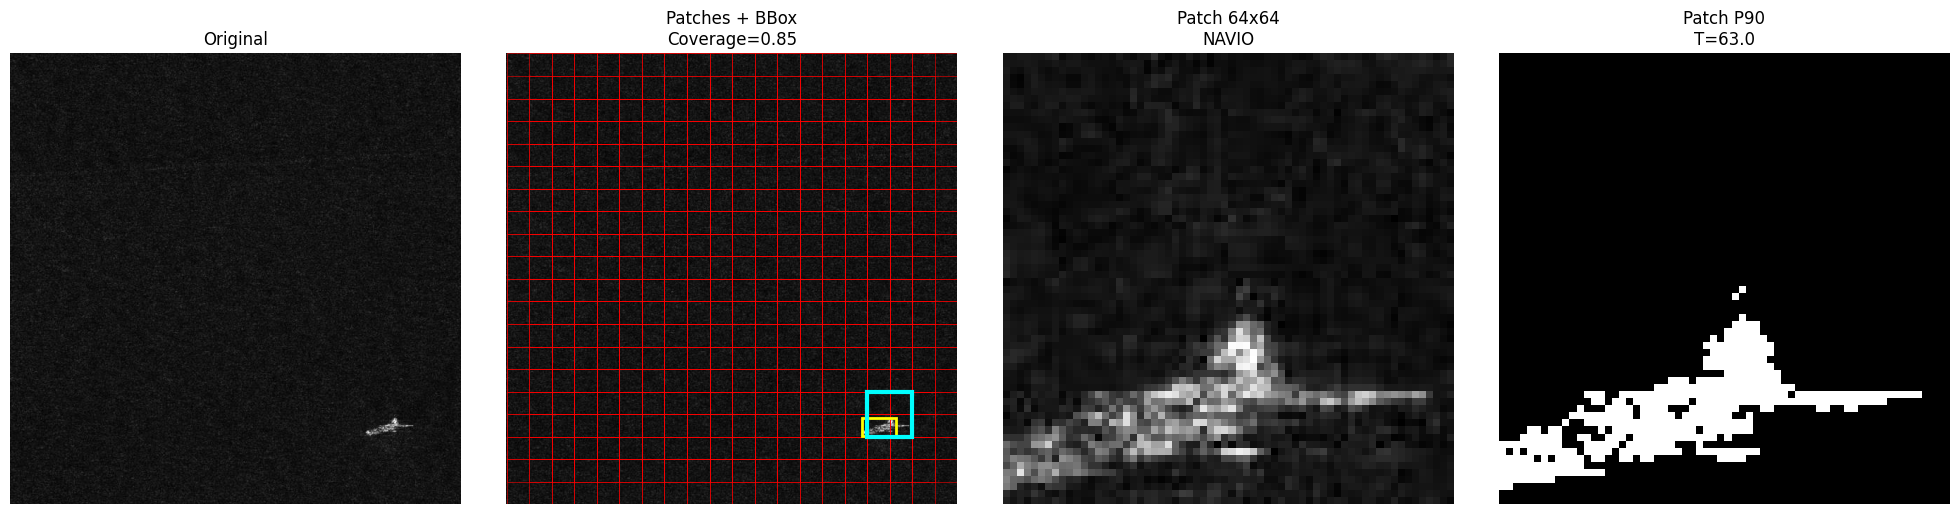

In [67]:
item = train_dataset[0]

image = Image.open(item["image"]).convert("L")
image_array = np.array(image)

patches_list = generate_patches(image.width, image.height, patch_size=64, stride=32)
gt_boxes = [coco_to_xyxy(box["bbox"]) for box in item["boxes"]]

best_patch = None
best_coverage = 0

for p in patches_list:
    patch_box = patch_to_xyxy(p)

    for gt_box in gt_boxes:
        coverage = ship_coverage(patch_box, gt_box)

        if coverage > best_coverage:
            best_coverage = coverage
            best_patch = p

label = 1 if best_coverage >= 0.5 else 0

print("Patch selecionado:", best_patch)
print("Coverage:", round(best_coverage, 4))
print("Label:", label)
print("Classe:", "NAVIO" if label == 1 else "FUNDO")

patch_image = extract_patch(image, best_patch)
patch_array = np.array(patch_image)

threshold = np.percentile(patch_array, 90)
binary_patch = (patch_array >= threshold).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image_array, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(image_array, cmap="gray")

for p in patches_list:
    rect = patches.Rectangle(
        (p["x"], p["y"]), p["width"], p["height"],
        linewidth=0.4, edgecolor="red", facecolor="none"
    )
    axes[1].add_patch(rect)

for box in item["boxes"]:
    x, y, w, h = box["bbox"]

    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2, edgecolor="yellow", facecolor="none"
    )
    axes[1].add_patch(rect)

rect = patches.Rectangle(
    (best_patch["x"], best_patch["y"]),
    best_patch["width"], best_patch["height"],
    linewidth=3, edgecolor="cyan", facecolor="none"
)

axes[1].add_patch(rect)
axes[1].set_title(f"Patches + BBox\nCoverage={best_coverage:.2f}")
axes[1].axis("off")

axes[2].imshow(patch_array, cmap="gray")
axes[2].set_title(f"Patch 64x64\n{'NAVIO' if label == 1 else 'FUNDO'}")
axes[2].axis("off")

axes[3].imshow(binary_patch, cmap="gray")
axes[3].set_title(f"Patch P90\nT={threshold:.1f}")
axes[3].axis("off")

plt.tight_layout()
plt.show()

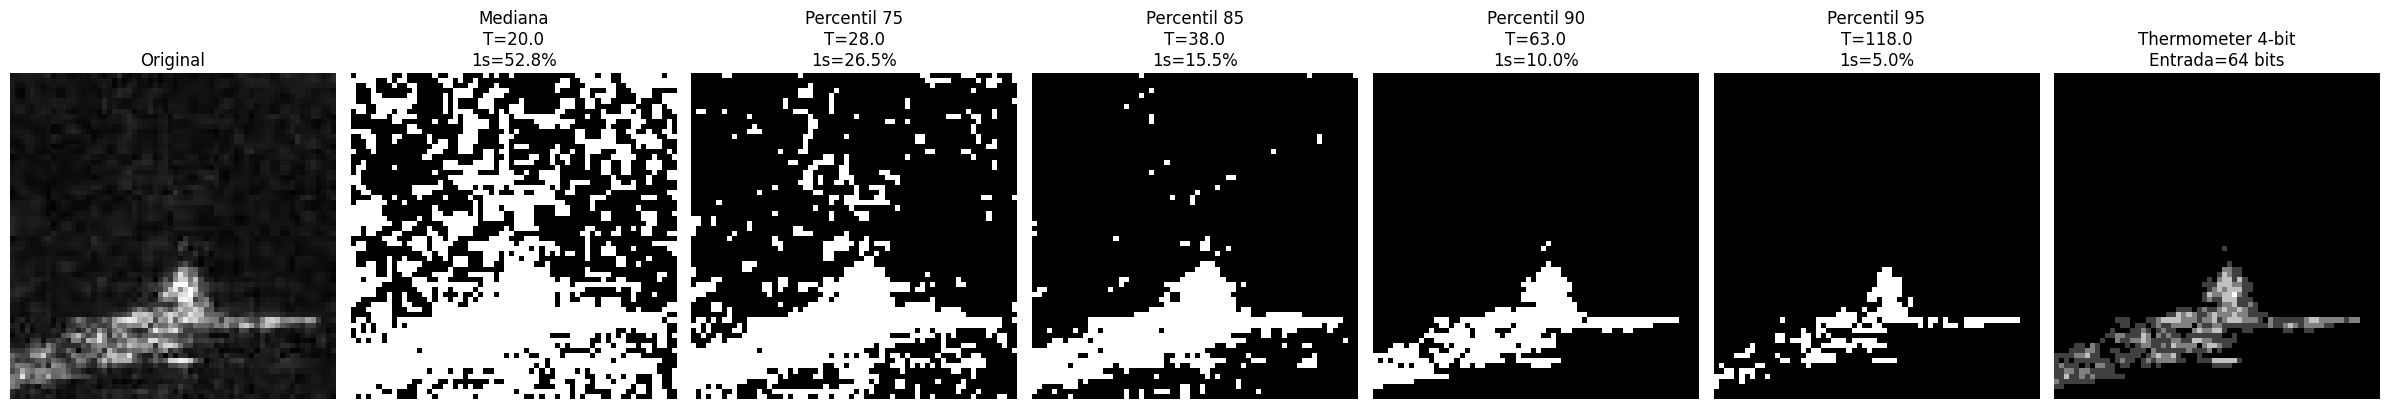

In [68]:
patch_array = np.array(patch_image)

thresholds = [
    np.median(patch_array),
    np.percentile(patch_array, 75),
    np.percentile(patch_array, 85),
    np.percentile(patch_array, 90),
    np.percentile(patch_array, 95)
]

titles = [
    "Mediana",
    "Percentil 75",
    "Percentil 85",
    "Percentil 90",
    "Percentil 95"
]

thermo_flat = thermometer_encode_array(patch_array, n_bits=4)

thermo = np.array(thermo_flat, dtype=np.uint8).reshape(
    patch_array.shape[0],
    patch_array.shape[1],
    4
)

thermo_visual = thermo.sum(axis=2)

fig, axes = plt.subplots(1, 7, figsize=(24, 4))

axes[0].imshow(patch_array, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for ax, threshold, title in zip(axes[1:6], thresholds, titles):
    binary = (patch_array >= threshold).astype(np.uint8)

    ax.imshow(binary, cmap="gray")
    ax.set_title(
        f"{title}\n"
        f"T={threshold:.1f}\n"
        f"1s={binary.mean() * 100:.1f}%"
    )
    ax.axis("off")

axes[6].imshow(thermo_visual, cmap="gray", vmin=0, vmax=4)
axes[6].set_title(
    f"Thermometer 4-bit\n"
    f"Entrada={len(thermo_flat)} bits"
)
axes[6].axis("off")

plt.tight_layout()
plt.show()

### Experimento com encoders

In [69]:
def sample_balanced(dataset, n_per_class=2000, seed=42):
    random.seed(seed)

    positives = [item for item in dataset if item["label"] == 1]

    negatives = [item for item in dataset if item["label"] == 0]

    n = min(n_per_class, len(positives), len(negatives))

    positives = random.sample(positives, n)
    negatives = random.sample(negatives, n)

    sampled = positives + negatives

    random.shuffle(sampled)

    return sampled

In [70]:
train_sample = sample_balanced(train_patches, n_per_class=10000)

print(Counter(item["label"] for item in train_sample))

Counter({0: 10000, 1: 10000})


In [71]:
def prepare_patch_for_wisard(item, percentile):
    binary = binarize_patch(item, percentile)

    return binary.flatten().tolist()

train_encoding_sample = sample_balanced(train_patches, n_per_class=10000, seed=42)
valid_encoding_sample = sample_balanced(valid_patches, n_per_class=1000, seed=42)

print("Treino:", Counter(item["label"] for item in train_encoding_sample))
print("Validação:", Counter(item["label"] for item in valid_encoding_sample))


Treino: Counter({0: 10000, 1: 10000})
Validação: Counter({0: 1000, 1: 1000})


In [72]:
def prepare_dataset_for_encoding(dataset, encoding):
    X = []
    y = []

    for item in dataset:
        if encoding == "P50":
            encoded = prepare_patch_for_wisard(item, percentile=50)
        elif encoding == "P90":
            encoded = prepare_patch_for_wisard(item, percentile=90)
        elif encoding == "Thermometer":
            encoded = thermometer_encode_patch(item, n_bits=4)
        else:
            raise ValueError(f"Codificação inválida: {encoding}")

        X.append(encoded)
        y.append("ship" if item["label"] == 1 else "background")

    return X, y

In [75]:
encodings = ["P50", "P90", "Thermometer"]
address_size = 8

encoding_results = []
encoding_reports = {}
encoding_confusion_matrices = {}
encoding_models = {}

for encoding in encodings:
    print("=" * 60)
    print("Codificação:", encoding)

    X_train_encoding, y_train_encoding = prepare_dataset_for_encoding(train_encoding_sample, encoding)

    X_valid_encoding, y_valid_encoding = prepare_dataset_for_encoding(valid_encoding_sample, encoding)

    print("Treino:", len(X_train_encoding))
    print("Validação:", len(X_valid_encoding))
    print("Bits por entrada:", len(X_train_encoding[0]))

    model_encoding = wp.Wisard(address_size, ignoreZero=False, verbose=False)

    model_encoding.train(X_train_encoding, y_train_encoding)

    pred = model_encoding.classify(X_valid_encoding)

    report = classification_report(y_valid_encoding, pred, output_dict=True, zero_division=0)

    cm = confusion_matrix(y_valid_encoding, pred, labels=["background", "ship"])

    encoding_models[encoding] = model_encoding
    encoding_reports[encoding] = report
    encoding_confusion_matrices[encoding] = cm

    encoding_results.append({
        "encoding": encoding,
        "input_bits": len(X_train_encoding[0]),
        "ship_precision": report["ship"]["precision"],
        "ship_recall": report["ship"]["recall"],
        "ship_f1": report["ship"]["f1-score"],
        "accuracy": report["accuracy"]
    })

    print(classification_report(y_valid_encoding, pred, digits=4, zero_division=0))

encoding_results_df = pd.DataFrame(encoding_results)
encoding_results_df

Codificação: P50
Treino: 20000
Validação: 2000
Bits por entrada: 4096
              precision    recall  f1-score   support

  background     0.5128    0.9650    0.6697      1000
        ship     0.7034    0.0830    0.1485      1000

    accuracy                         0.5240      2000
   macro avg     0.6081    0.5240    0.4091      2000
weighted avg     0.6081    0.5240    0.4091      2000

Codificação: P90
Treino: 20000
Validação: 2000
Bits por entrada: 4096
              precision    recall  f1-score   support

  background     0.6504    0.9620    0.7761      1000
        ship     0.9271    0.4830    0.6351      1000

    accuracy                         0.7225      2000
   macro avg     0.7888    0.7225    0.7056      2000
weighted avg     0.7888    0.7225    0.7056      2000

Codificação: Thermometer
Treino: 20000
Validação: 2000
Bits por entrada: 16384
              precision    recall  f1-score   support

  background     0.9851    0.8610    0.9189      1000
        ship     0

,encoding,input_bits,ship_precision,ship_recall,ship_f1,accuracy
0,P50,4096,0.703390,0.083,0.148479,0.5240
1,P90,4096,0.927063,0.483,0.635108,0.7225
2,Thermometer,16384,0.876554,0.987,0.928504,0.9240


In [76]:
test_sample = sample_balanced(test_patches, n_per_class=1000, seed=42)

In [80]:
def predict_image_with_encoding(image_path, model, encoding, patch_size=64, stride=32):
    image = Image.open(image_path).convert("L")
    patches_list = generate_patches(image.width, image.height, patch_size=patch_size, stride=stride)

    predictions = []

    for patch_info in patches_list:
        patch_image = extract_patch(image, patch_info)
        patch_array = np.array(patch_image)

        if encoding == "P50":
            threshold = np.percentile(patch_array, 50)
            encoded = (patch_array >= threshold).astype(np.uint8).flatten().tolist()

        elif encoding == "P90":
            threshold = np.percentile(patch_array, 90)
            encoded = (patch_array >= threshold).astype(np.uint8).flatten().tolist()

        elif encoding == "Thermometer":
            encoded = thermometer_encode_array(patch_array, n_bits=4).flatten().tolist()

        else:
            raise ValueError(f"Codificação inválida: {encoding}")

        predicted_label = model.classify([encoded])[0]

        predictions.append({
            "x": patch_info["x"],
            "y": patch_info["y"],
            "width": patch_info["width"],
            "height": patch_info["height"],
            "prediction": predicted_label
        })

    return predictions

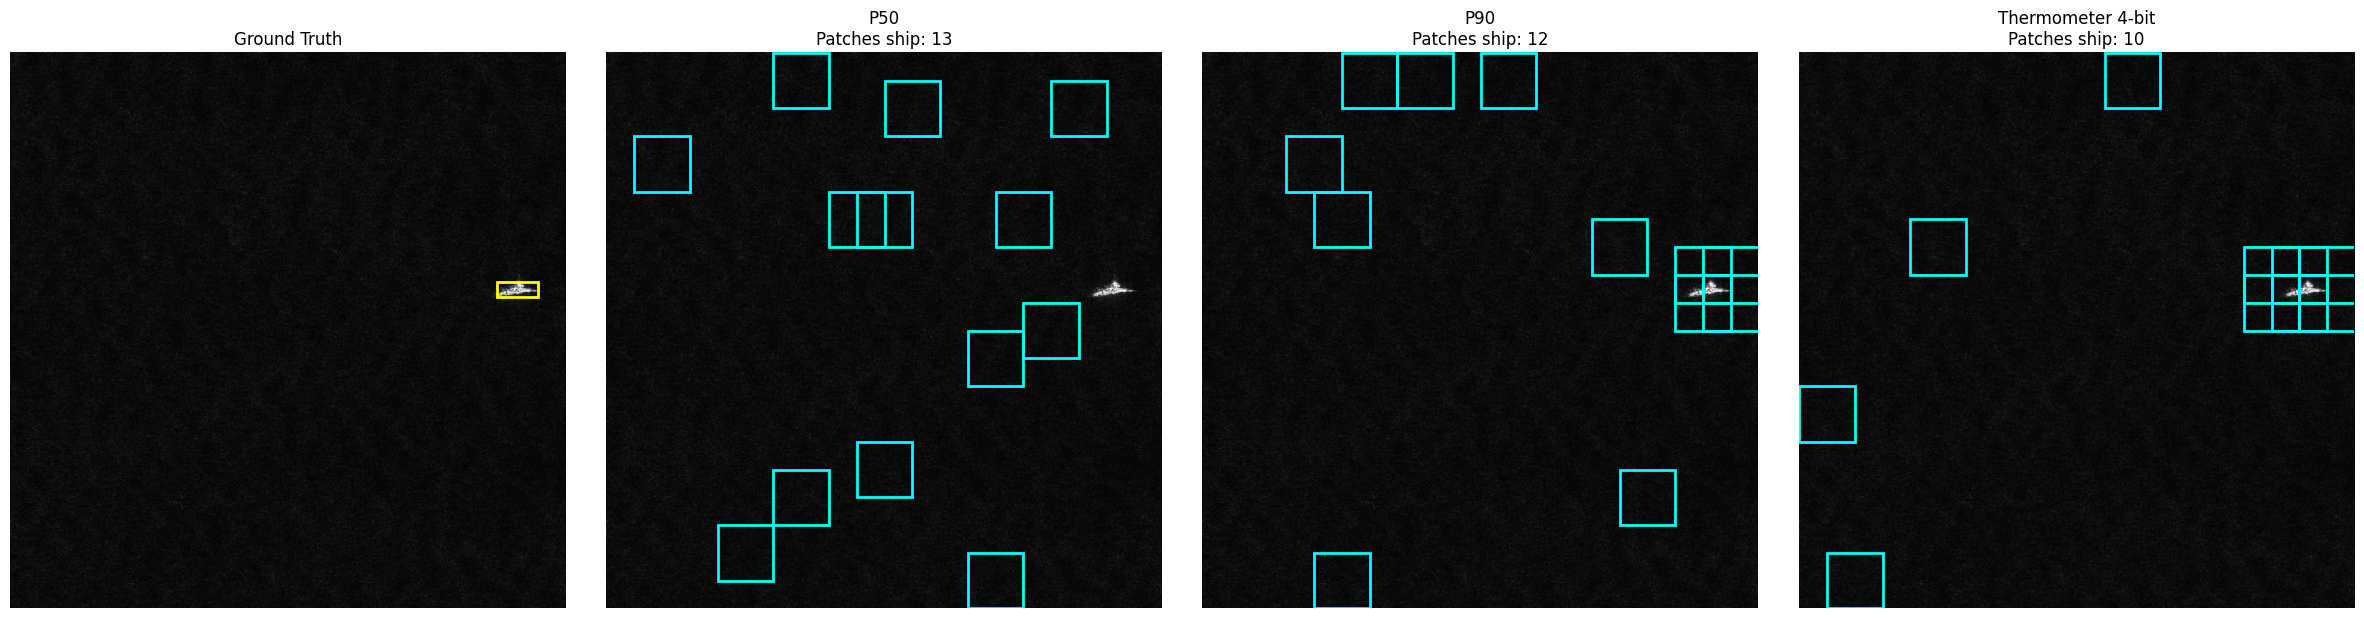

In [ ]:
item = test_dataset[0]
image_path = item["image"]

predictions_p50 = predict_image_with_encoding(image_path, encoding_models["P50"], "P50")

predictions_p90 = predict_image_with_encoding(image_path, encoding_models["P90"], "P90")

predictions_thermo = predict_image_with_encoding(image_path, encoding_models["Thermometer"], "Thermometer")

image = Image.open(image_path).convert("L")

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

axes[0].imshow(image, cmap="gray")

for box in item["boxes"]:
    x, y, w, h = box["bbox"]

    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2, edgecolor="yellow", facecolor="none"
    )

    axes[0].add_patch(rect)

axes[0].set_title("Ground Truth")
axes[0].axis("off")

prediction_sets = [("P50", predictions_p50), ("P90", predictions_p90), ("Thermometer 4-bit", predictions_thermo)]

for ax, (title, predictions) in zip(axes[1:], prediction_sets):
    ax.imshow(image, cmap="gray")

    ship_count = 0

    for pred in predictions:
        if pred["prediction"] != "ship":
            continue

        ship_count += 1

        rect = patches.Rectangle(
            (pred["x"], pred["y"]),
            pred["width"],
            pred["height"],
            linewidth=2,
            edgecolor="cyan",
            facecolor="none"
        )

        ax.add_patch(rect)

    ax.set_title(f"{title}\nPatches ship: {ship_count}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Address Size

In [82]:
X_train_thermo, y_train_thermo = prepare_dataset_for_encoding(train_encoding_sample, "Thermometer")

X_valid_thermo, y_valid_thermo = prepare_dataset_for_encoding(valid_encoding_sample, "Thermometer")

In [83]:
address_sizes = [4, 6, 8, 10, 12, 14, 16, 32, 64]

address_results = []
address_models = {}

for address_size in address_sizes:
    print("=" * 50)
    print("Address size:", address_size)

    model_test = wp.Wisard(address_size, ignoreZero=False, verbose=False)

    model_test.train(X_train_thermo, y_train_thermo)

    pred = model_test.classify(X_valid_thermo)

    report = classification_report(y_valid_thermo, pred, output_dict=True, zero_division=0)

    address_models[address_size] = model_test

    address_results.append({
        "address_size": address_size,
        "ship_precision": report["ship"]["precision"],
        "ship_recall": report["ship"]["recall"],
        "ship_f1": report["ship"]["f1-score"],
        "accuracy": report["accuracy"]
    })

    print(classification_report(y_valid_thermo, pred, digits=4, zero_division=0))

Address size: 4
              precision    recall  f1-score   support

  background     0.9715    0.4770    0.6398      1000
        ship     0.6534    0.9860    0.7860      1000

    accuracy                         0.7315      2000
   macro avg     0.8124    0.7315    0.7129      2000
weighted avg     0.8124    0.7315    0.7129      2000

Address size: 6
              precision    recall  f1-score   support

  background     0.9662    0.7430    0.8400      1000
        ship     0.7912    0.9740    0.8732      1000

    accuracy                         0.8585      2000
   macro avg     0.8787    0.8585    0.8566      2000
weighted avg     0.8787    0.8585    0.8566      2000

Address size: 8
              precision    recall  f1-score   support

  background     0.9828    0.8550    0.9144      1000
        ship     0.8717    0.9850    0.9249      1000

    accuracy                         0.9200      2000
   macro avg     0.9272    0.9200    0.9197      2000
weighted avg     0.9272   

In [85]:
address_results_df = pd.DataFrame(address_results)

address_results_df

,address_size,ship_precision,ship_recall,ship_f1,accuracy
0,4,0.653413,0.986,0.785971,0.7315
1,6,0.791227,0.974,0.873151,0.8585
2,8,0.871681,0.985,0.924883,0.9200
3,10,0.891107,0.982,0.934348,0.9310
4,12,0.903226,0.980,0.940048,0.9375
5,14,0.903468,0.964,0.932753,0.9305
6,16,0.908491,0.963,0.934951,0.9330
7,32,0.908491,0.963,0.934951,0.9330
8,64,0.873563,0.988,0.927264,0.9225


### Final model

In [104]:
variables_to_delete = [
    "train_sample",
    "train_encoding_sample",
    "valid_encoding_sample",
    "X_train_encoding",
    "y_train_encoding",
    "X_valid_encoding",
    "y_valid_encoding",
    "model_encoding",
    "pred",
    "report",
    "cm",
    "encoding_models",
    "encoding_reports",
    "encoding_confusion_matrices",
    "encoding_results",
    "encoding_results_df",
    "test_sample",
    "predictions_p50",
    "predictions_p90",
    "predictions_thermo",
    "prediction_sets",
    "X_train_thermo",
    "y_train_thermo",
    "X_valid_thermo",
    "y_valid_thermo",
    "address_models",
    "address_results",
    "address_results_df",
    "model_test"
]

for var in variables_to_delete:
    globals().pop(var, None)

gc.collect()

34281

In [16]:
def sample_with_ratio_limit(dataset, n_positive=9000, negative_ratio=10, seed=42):
    random.seed(seed)

    positives = [x for x in dataset if x["label"] == 1]
    negatives = [x for x in dataset if x["label"] == 0]

    n_positive = min(n_positive, len(positives))

    positives = random.sample(positives, n_positive)

    n_negative = min(len(negatives), n_positive * negative_ratio)

    negatives = random.sample(negatives, n_negative)

    result = positives + negatives
    random.shuffle(result)

    return result

In [ ]:
train_final_thermo = sample_with_ratio_limit(train_patches, n_positive=5000, negative_ratio=40, seed=42)

print("Distribuição treino final:")
print(Counter(item["label"] for item in train_final_thermo))

Distribuição treino final:
Counter({0: 50000, 1: 5000})


In [18]:
X_train_final_thermo = []
y_train_final_thermo = []

for item in train_final_thermo:
    X_train_final_thermo.append(thermometer_encode_patch(item, n_bits=4))
    y_train_final_thermo.append("ship" if item["label"] == 1 else "background")

print("Quantidade de treino:", len(X_train_final_thermo))
print("Bits por entrada:", len(X_train_final_thermo[0]))


Quantidade de treino: 55000
Bits por entrada: 16384


In [22]:
final_model_thermo = wp.Wisard(32, ignoreZero=False, verbose=True)

In [23]:
final_model_thermo.train(X_train_final_thermo, y_train_final_thermo)

In [ ]:
valid_sample_thermo = sample_with_ratio_limit(valid_patches, n_positive=1000, negative_ratio=10, seed=42)

print(Counter(item["label"] for item in valid_sample_thermo))

Counter({0: 10000, 1: 1000})


In [24]:
X_valid_final_thermo = []
y_valid_final_thermo = []

for item in valid_sample_thermo:
    X_valid_final_thermo.append(thermometer_encode_patch(item, n_bits=4))
    y_valid_final_thermo.append("ship" if item["label"] == 1 else "background")

y_valid_pred_final_thermo = final_model_thermo.classify(X_valid_final_thermo)

print(classification_report(y_valid_final_thermo, y_valid_pred_final_thermo, digits=4, zero_division=0))

              precision    recall  f1-score   support

  background     0.9709    0.9814    0.9761     10000
        ship     0.7915    0.7060    0.7463      1000

    accuracy                         0.9564     11000
   macro avg     0.8812    0.8437    0.8612     11000
weighted avg     0.9546    0.9564    0.9552     11000



Tamanho da entrada: 16384
Patch selecionado: {'x': 544, 'y': 224, 'width': 64, 'height': 64}
Coverage: 1.0

Ground Truth: ship
WiSARD: ship
Resultado: CORRETO


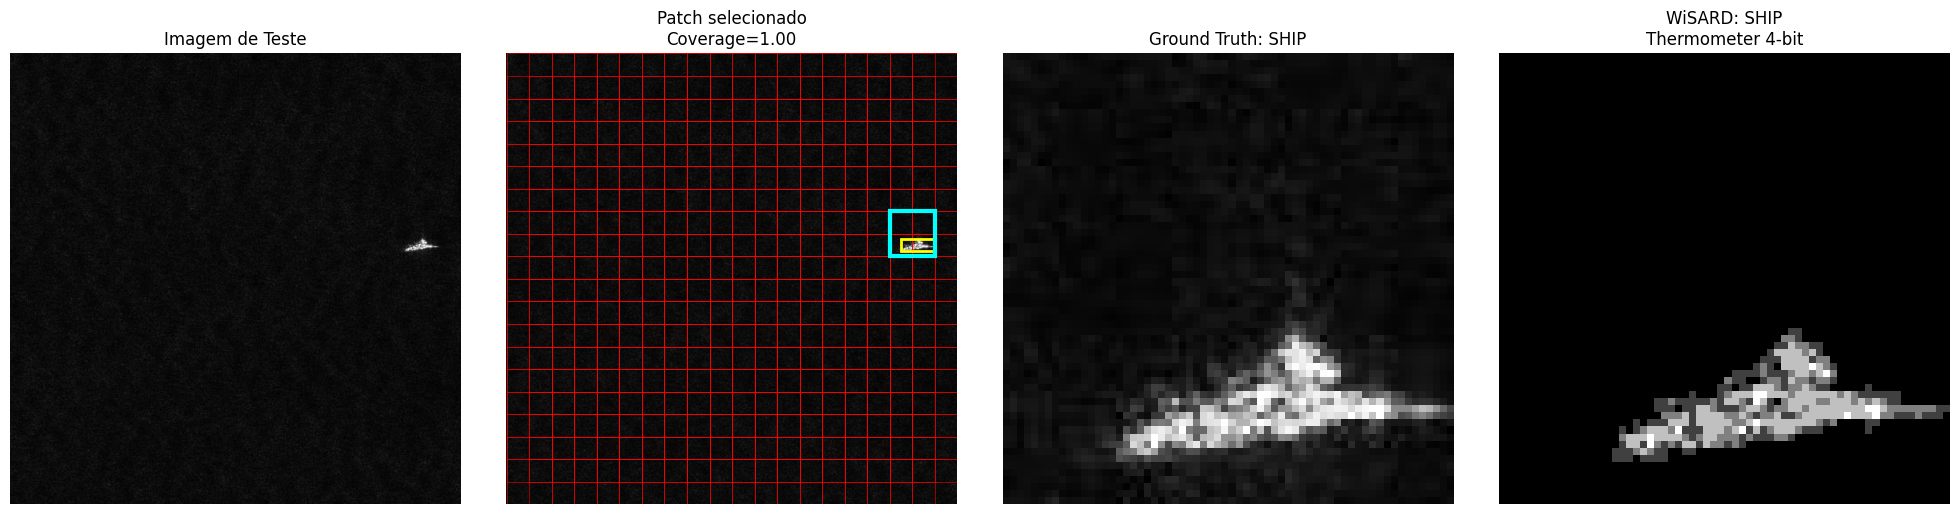

In [25]:
item = test_dataset[0]

image = Image.open(item["image"]).convert("L")
image_array = np.array(image)

patches_list = generate_patches(image.width, image.height, patch_size=64, stride=32)
gt_boxes = [coco_to_xyxy(box["bbox"]) for box in item["boxes"]]

best_patch = None
best_coverage = 0

for p in patches_list:
    patch_box = patch_to_xyxy(p)

    for gt_box in gt_boxes:
        coverage = ship_coverage(patch_box, gt_box)

        if coverage > best_coverage:
            best_coverage = coverage
            best_patch = p

true_label = "ship" if best_coverage >= 0.5 else "background"

patch_image = extract_patch(image, best_patch)
patch_array = np.array(patch_image)

# THERMOMETER 4-BIT
thermo = thermometer_encode_array(patch_array, n_bits=4)
wisard_input = thermo.flatten().tolist()
thermo_visual = thermo.sum(axis=2)

print("Tamanho da entrada:", len(wisard_input))

# PREVISÃO
predicted_label = final_model_thermo.classify([wisard_input])[0]

print("Patch selecionado:", best_patch)
print("Coverage:", round(best_coverage, 4))
print()
print("Ground Truth:", true_label)
print("WiSARD:", predicted_label)
print("Resultado:", "CORRETO" if predicted_label == true_label else "ERRADO")

# PLOT
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image_array, cmap="gray")
axes[0].set_title("Imagem de Teste")
axes[0].axis("off")

axes[1].imshow(image_array, cmap="gray")

for p in patches_list:
    rect = patches.Rectangle(
        (p["x"], p["y"]), p["width"], p["height"],
        linewidth=0.4, edgecolor="red", facecolor="none"
    )
    axes[1].add_patch(rect)

for box in item["boxes"]:
    x, y, w, h = box["bbox"]

    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2, edgecolor="yellow", facecolor="none"
    )
    axes[1].add_patch(rect)

rect = patches.Rectangle(
    (best_patch["x"], best_patch["y"]),
    best_patch["width"], best_patch["height"],
    linewidth=3, edgecolor="cyan", facecolor="none"
)

axes[1].add_patch(rect)
axes[1].set_title(f"Patch selecionado\nCoverage={best_coverage:.2f}")
axes[1].axis("off")

axes[2].imshow(patch_array, cmap="gray")
axes[2].set_title(f"Ground Truth: {true_label.upper()}")
axes[2].axis("off")

axes[3].imshow(thermo_visual, cmap="gray", vmin=0, vmax=4)
axes[3].set_title(
    f"WiSARD: {predicted_label.upper()}\n"
    f"Thermometer 4-bit"
)
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [26]:
def predict_image(image_path, model, patch_size=64, stride=32, n_bits=4):
    image = Image.open(image_path).convert("L")

    patches_list = generate_patches(image.width, image.height, patch_size=patch_size, stride=stride)

    predictions = []

    for patch_info in patches_list:

        patch_image = extract_patch(image, patch_info)

        patch_array = np.array(patch_image).astype(np.float32)

        min_val = patch_array.min()
        max_val = patch_array.max()

        if max_val == min_val:
            normalized = np.zeros_like(patch_array)
        else:
            normalized = ((patch_array - min_val)/ (max_val - min_val))

        levels = np.floor(normalized * n_bits).astype(int)

        levels = np.clip(levels, 0, n_bits)

        encoded = np.zeros((*patch_array.shape, n_bits), dtype=np.uint8)

        for i in range(n_bits):
            encoded[:, :, i] = (levels > i).astype(np.uint8)

        wisard_input = (encoded.flatten().tolist())

        predicted_label = model.classify([wisard_input])[0]

        predictions.append({
            "x": patch_info["x"],
            "y": patch_info["y"],
            "width": patch_info["width"],
            "height": patch_info["height"],
            "prediction": predicted_label,
            "score": None
        })

    return predictions

In [27]:
def plot_predictions(image_path, predictions):

    image = Image.open(image_path).convert("L")

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(image, cmap="gray")

    ship_count = 0

    for pred in predictions:

        if pred["prediction"] != "ship":
            continue

        ship_count += 1

        x = pred["x"]
        y = pred["y"]
        w = pred["width"]
        h = pred["height"]

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="cyan",
            facecolor="none"
        )

        ax.add_patch(rect)
        if pred["score"] is not None:
            label = (
                f"SHIP "
                f"(score={pred['score']:.2f})"
            )
        else:
            label = "SHIP"

        ax.text(
            x,
            y - 5,
            label,
            fontsize=9,
            bbox=dict(
                facecolor="white",
                alpha=0.7,
                edgecolor="none"
            )
        )

    ax.set_title(
        f"WiSARD - Ships detectados: {ship_count}"
    )

    ax.axis("off")

    plt.tight_layout()
    plt.show()

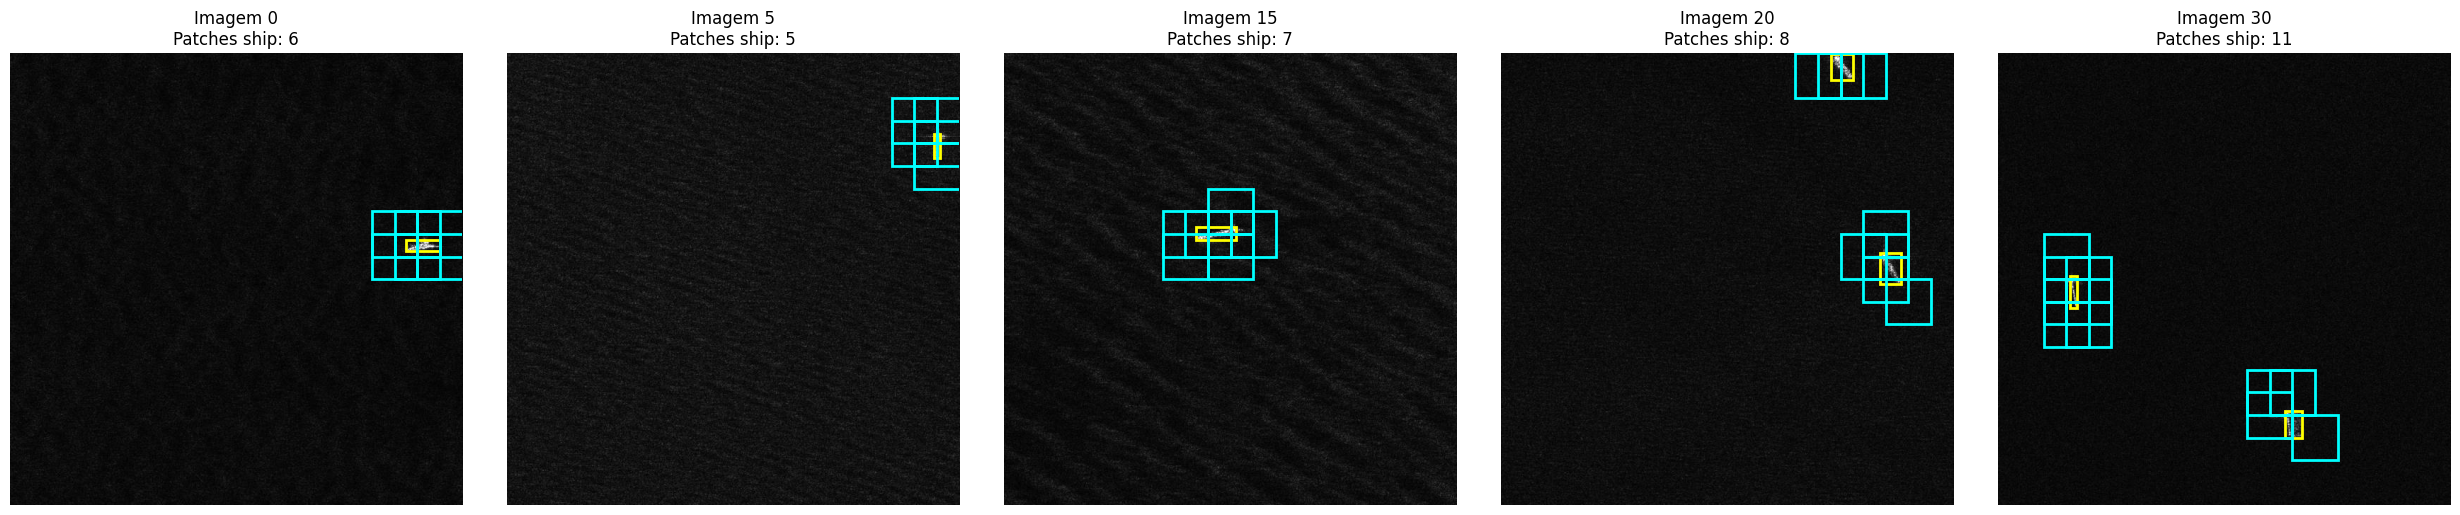

In [28]:
indices = [0, 5, 15, 20, 30]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, idx in zip(axes, indices):
    item = test_dataset[idx]
    image_path = item["image"]

    image = Image.open(image_path).convert("L")
    predictions = predict_image(image_path, final_model_thermo)

    ax.imshow(image, cmap="gray")

    for box in item["boxes"]:
        x, y, w, h = box["bbox"]

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="yellow",
            facecolor="none"
        )

        ax.add_patch(rect)

    ship_count = 0

    for pred in predictions:
        if pred["prediction"] != "ship":
            continue

        ship_count += 1

        rect = patches.Rectangle(
            (pred["x"], pred["y"]),
            pred["width"],
            pred["height"],
            linewidth=2,
            edgecolor="cyan",
            facecolor="none"
        )

        ax.add_patch(rect)

    ax.set_title(
        f"Imagem {idx}\n"
        f"Patches ship: {ship_count}")

    ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
test_sample_thermo = sample_with_ratio_limit(test_patches, n_positive=1000, negative_ratio=40, seed=42)

print("Distribuição do teste:", Counter(item["label"] for item in test_sample_thermo))

X_test_thermo = []
y_test_thermo = []

for item in test_sample_thermo:
    X_test_thermo.append(thermometer_encode_patch(item, n_bits=4))

    y_test_thermo.append("ship" if item["label"] == 1 else "background")

print("Quantidade de exemplos:", len(X_test_thermo))
print("Tamanho da entrada:", len(X_test_thermo[0]))

y_test_pred_thermo = final_model_thermo.classify(X_test_thermo)

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test_thermo, y_test_pred_thermo, digits=4, zero_division=0))

cm = confusion_matrix(y_test_thermo, y_test_pred_thermo, labels=["background", "ship"])

print("\nCONFUSION MATRIX")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nRESULTADOS")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

report = classification_report(y_test_thermo, y_test_pred_thermo, output_dict=True, zero_division=0)

print("\nSHIP")
print(f"Precision: {report['ship']['precision']:.4f}")
print(f"Recall:    {report['ship']['recall']:.4f}")
print(f"F1-score:  {report['ship']['f1-score']:.4f}")
print(f"Accuracy:  {accuracy_score(y_test_thermo, y_test_pred_thermo):.4f}")

Distribuição do teste: Counter({0: 40000, 1: 1000})
Quantidade de exemplos: 41000
Tamanho da entrada: 16384

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  background     0.9917    0.9811    0.9864     40000
        ship     0.4713    0.6730    0.5544      1000

    accuracy                         0.9736     41000
   macro avg     0.7315    0.8271    0.7704     41000
weighted avg     0.9790    0.9736    0.9759     41000


CONFUSION MATRIX
[[39245   755]
 [  327   673]]

RESULTADOS
True Negatives:  39245
False Positives: 755
False Negatives: 327
True Positives:  673

SHIP
Precision: 0.4713
Recall:    0.6730
F1-score:  0.5544
Accuracy:  0.9736
